In [1]:
import os
import sys
import numpy as np

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# Add src directory to Python path for imports
sys.path.append(os.path.abspath('../../src'))

# Import from our package
from fiber_predictor.svr_hog.feature_extraction import HogFeatureExtractor
from fiber_predictor.svr_hog.data_processing import HogDataset, balance_dataset
from fiber_predictor.svr_hog.models import FiberPredictor


In [9]:
def plot_angle_predictions(true_angles, pred_angles, mae, title="Model Predictions vs True Values"):
    """Plot predicted vs true angles with error bounds"""
    plt.figure(figsize=(8, 3))
    plt.plot(true_angles, pred_angles, 'b.', label='Predictions')
    plt.plot([0, 180], [0, 180], 'k--')
    plt.fill_between(np.array([0, 180]), 
                     np.array([0, 180])-mae, 
                     np.array([0, 180])+mae, 
                     color='gray', 
                     alpha=0.2, 
                     label=f'±{mae:.1f}° Error')

    plt.xlabel('True Angle (degrees)')
    plt.ylabel('Predicted Angle (degrees)')
    plt.title(title)
    # move legend outside of the plot
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.grid(True)
    plt.xlim([-5, 185])
    plt.show()


In [10]:
# Create datasets
bio_file_dir = "../../images/bio/"
bio_csv_dir = "../../images/bio/labels.csv"

diff_file_dir = "../../images/diffusion/"
diff_csv_dir = "../../images/diffusion/labels.csv"


grid_quotient_list = list(range(1, 6))
for i in range(2, 6):
    grid_quotient_list.append(list(range(1, i + 1)))

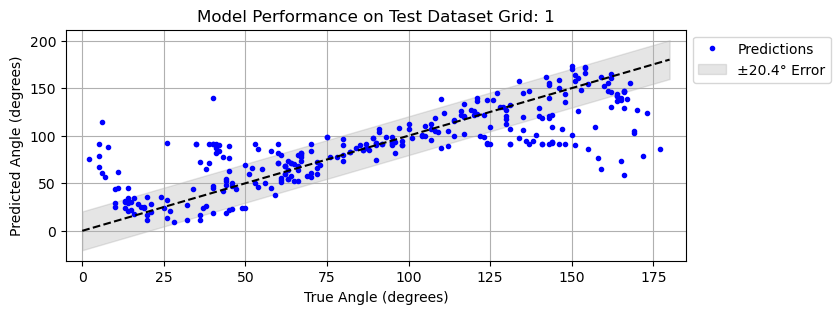

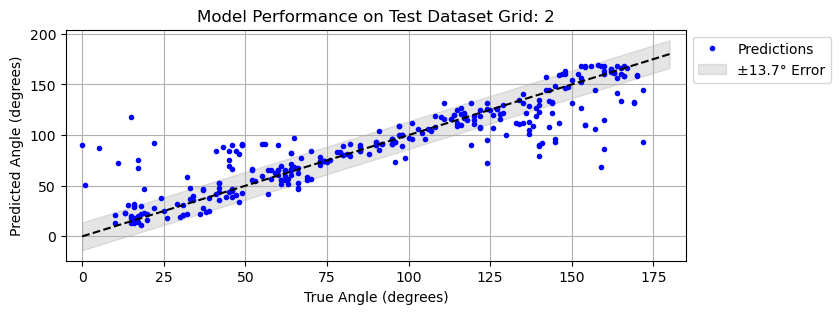

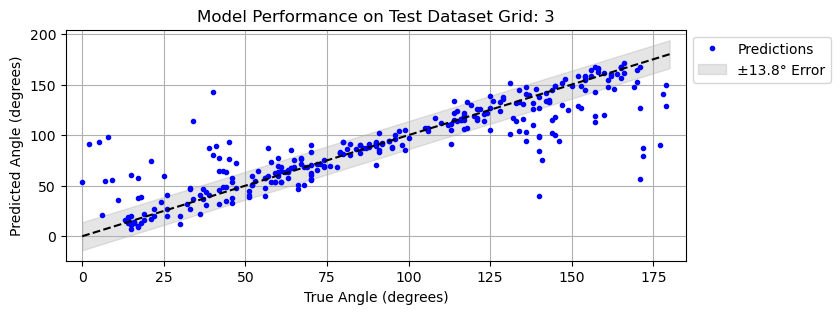

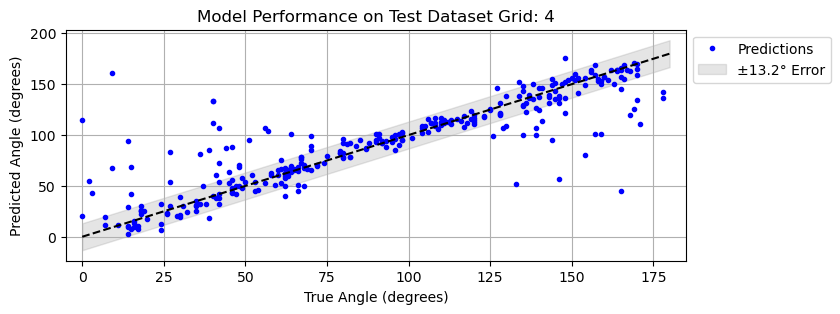

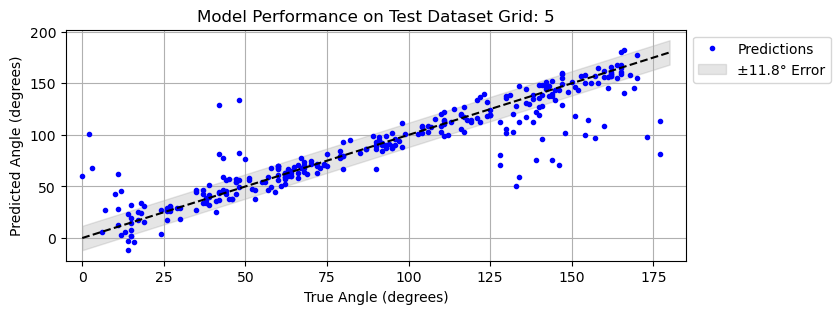

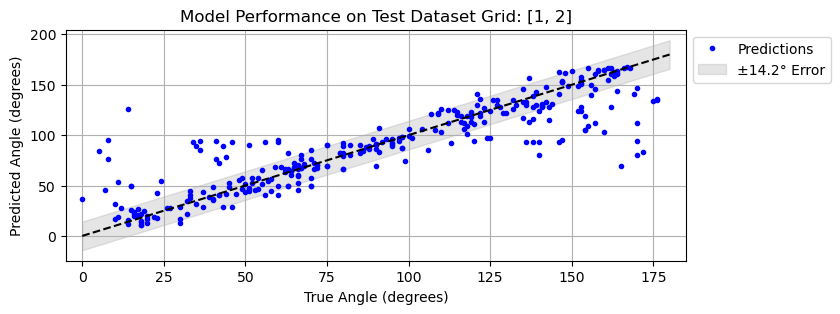

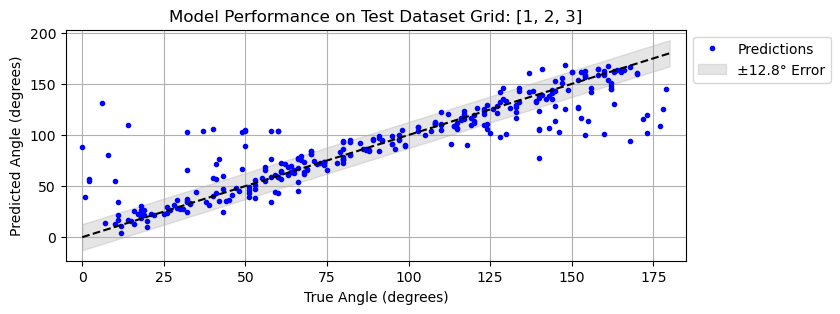

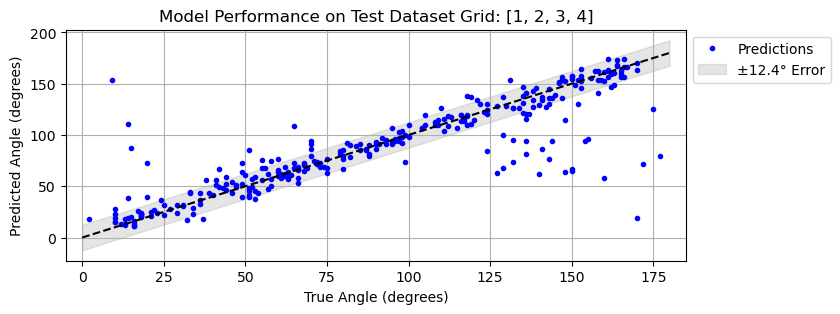

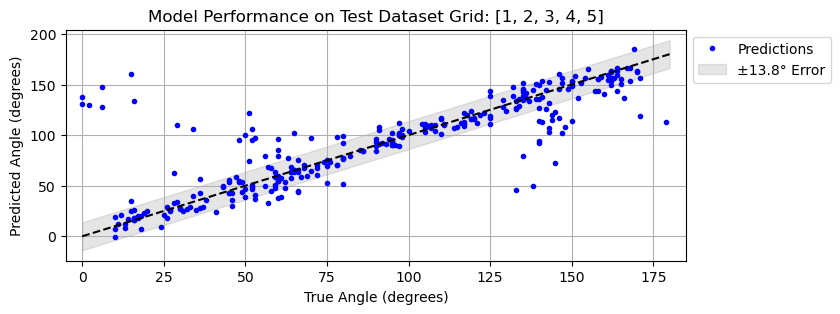

In [11]:
# Dataset parameters
for grid_quotient in grid_quotient_list:
    orientations = 8

    # Load biological dataset with augmentation
    bio_dataset = HogDataset(
        labels_path=bio_csv_dir,
        file_dir=bio_file_dir,
        grid_quotient=grid_quotient,
        orientations=orientations,
        augment_whole_dataset=True
    )

    # Balance the dataset
    bins = np.arange(0, 181, 20)  # 20-degree bins so the dataset is not reduced too much
    balance_dataset(bio_dataset, bins)

    # Extract features for all images
    hog_extractor = HogFeatureExtractor(grid_quotient, orientations)
    feature_matrix = []
    labels = []

    for idx in range(len(bio_dataset)):
        img_tensor, features_tensor, angle = bio_dataset[idx]
        feature_matrix.append(features_tensor.numpy())
        labels.append(angle)

    feature_matrix = np.array(feature_matrix)
    labels = np.array(labels)

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        feature_matrix, 
        labels, 
        test_size=0.3, 
        random_state=42
    )

    # Initialize and train model
    model = FiberPredictor(
        scaler_type="Standard",
        pca_params={"n_components": 0.8},
        regressor_type="SVR",
        regressor_params={"kernel": "rbf", "C": 100, "gamma": 0.01}
    )

    model.fit(X_train, y_train)

    # Evaluate
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)

    # Plot test set results
    plot_angle_predictions(y_test, y_pred, mae, f'Model Performance on Test Dataset Grid: {grid_quotient}')
